In [ ]:
# In this notebook I simulate Grover's Algorithm in an n-qubit database

In [ ]:
!pip install qiskit numpy matplotlib qiskit[visualization]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 1.7 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=f6c79e458e97cddf7106c43327461eeff1025e6d3426dbedddc5e229fb2e5dd3
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [ ]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import PhaseOracle
from qiskit.circuit.library import GroverOperator
import numpy as np
import matplotlib.pyplot as plt
import math

In [ ]:
# This cell is for determining parameters of the algorithm, including how many qubits the circuit will have
n = 10

Target = np.random.randint(low=0, high=2, size=n)
print(Target)
# This creates a random bitstring that we will be searching for with Grover's Algorithm

[0 1 0 0 1 1 0 1 0 0]


In [ ]:
# We will now create the argument for the phase oracle gate

TargetExpression = ""
for i in range(n):
  if Target[i] == 1:
    TargetExpression += "x" + str(i) + " & "
  elif Target[i] == 0:
    TargetExpression += "~x" + str(i) + " & "

TargetExpression = TargetExpression[:-2]
#removes the & at the end

print(TargetExpression)

~x0 & x1 & ~x2 & ~x3 & x4 & x5 & ~x6 & x7 & ~x8 & ~x9 


/tmp/ipython-input-1585090231.py:9: DeprecationWarning: The class ``qiskit.circuit.library.phase_oracle.PhaseOracle`` is deprecated as of Qiskit 2.2. It will be removed in Qiskit 3.0. Use the class qiskit.circuit.library.PhaseOracleGate instead.
  Grovers = Grovers.compose(GroverOperator(PhaseOracle(TargetExpression)), range(n))
/tmp/ipython-input-1585090231.py:9: DeprecationWarning: The class ``qiskit.circuit.library.grover_operator.GroverOperator`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use qiskit.circuit.library.grover_operator instead.
  Grovers = Grovers.compose(GroverOperator(PhaseOracle(TargetExpression)), range(n))
/tmp/ipython-input-1585090231.py:9: DeprecationWarning: The class ``qiskit.circuit.library.phase_oracle.PhaseOracle`` is deprecated as of Qiskit 2.2. It will be removed in Qiskit 3.0. Use the class qiskit.circuit.library.PhaseOracleGate instead.
  Grovers = Grovers.compose(GroverOperator(PhaseOracle(TargetExpression)), range(n))
/tmp/ipytho

{'0010110010': 97, '1101010001': 1, '1001101010': 1, '1111111000': 1}


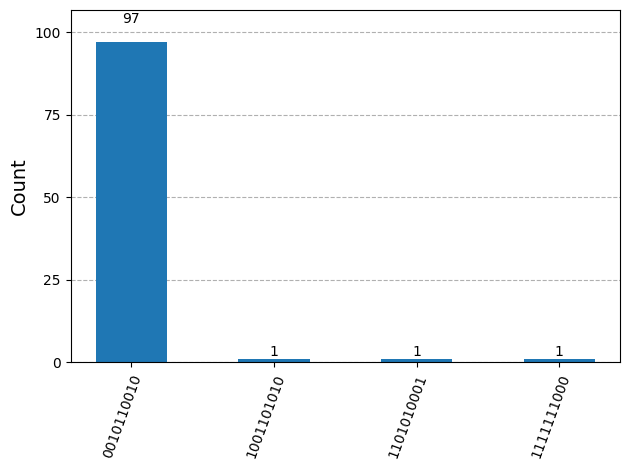

In [ ]:
# Here is the actual implementation of Grover's Algorithm

Grovers = QuantumCircuit(n)

Grovers.h(range(n))
for i in range(int(math.ceil(((math.pi)/4*(math.sqrt(2**n)))) + 1)):
# Calculates how many times Grover's operation needs to be applied to converge on the target string absolutely

  Grovers = Grovers.compose(GroverOperator(PhaseOracle(TargetExpression)), range(n))
  #Repeat the phase oracle and diffusion steps 27 times (when n = 10). 27 is approximately the number of iterations to optimally converge
  # Grover's Algorithm needs pi/4 * sqrt(2^n) = 25.13 iterations to converge absolutely


# Measure and record our qubits' states
Grovers.measure_all()
sampler = StatevectorSampler()
result = sampler.run([Grovers], shots = 100).result()
counts = result[0].data.meas.get_counts()
print(result[0].data.meas.get_counts())
plot_histogram(counts)

# YESSSSSS IT WORKSSSSS - Russell at time of completion

